# Task B-5: Model Explainability

**Project:** Torterm — AI Home Renovation Chatbot  
**Task:** Explain which text features drive the classifier's predictions  
**Method:** TF-IDF feature importance via Logistic Regression coefficients + LIME

In [1]:
import json, os, re, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Ready.')

Ready.


## 1. Load Data and Train Model

In [2]:
DATA_DIR = '../data'
files = ['homepro_exterior.json','con.json','dow.json','flo.json','out.json','pai.json']
records = []
for f in files:
    with open(os.path.join(DATA_DIR, f), encoding='utf-8') as fp:
        records.extend(json.load(fp))

cat_map = {
    'ประตูและหน้าต่าง': 'Door_Window',
    'วัสดุปูพื้นและผนัง': 'Floor_Wall',
    'วัสดุก่อสร้าง': 'Construction',
    'เฟอร์นิเจอร์นอกบ้านและสวน': 'Outdoor_Furniture',
    'สีและอุปกรณ์ทาสี': 'Paint_Tools'
}
df = pd.DataFrame(records)
df['label'] = df['category'].map(cat_map)
df['text'] = df['name'].fillna('') + ' ' + df['description'].fillna('')
df['text'] = df['text'].apply(lambda t: re.sub(r'\s+', ' ', re.sub(r'https?://\S+', '', t)).strip())

X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4), max_features=10000, sublinear_tf=True)),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])
pipeline.fit(X_train, y_train)
print('Model trained.')

Model trained.


## 2. Feature Importance via LR Coefficients

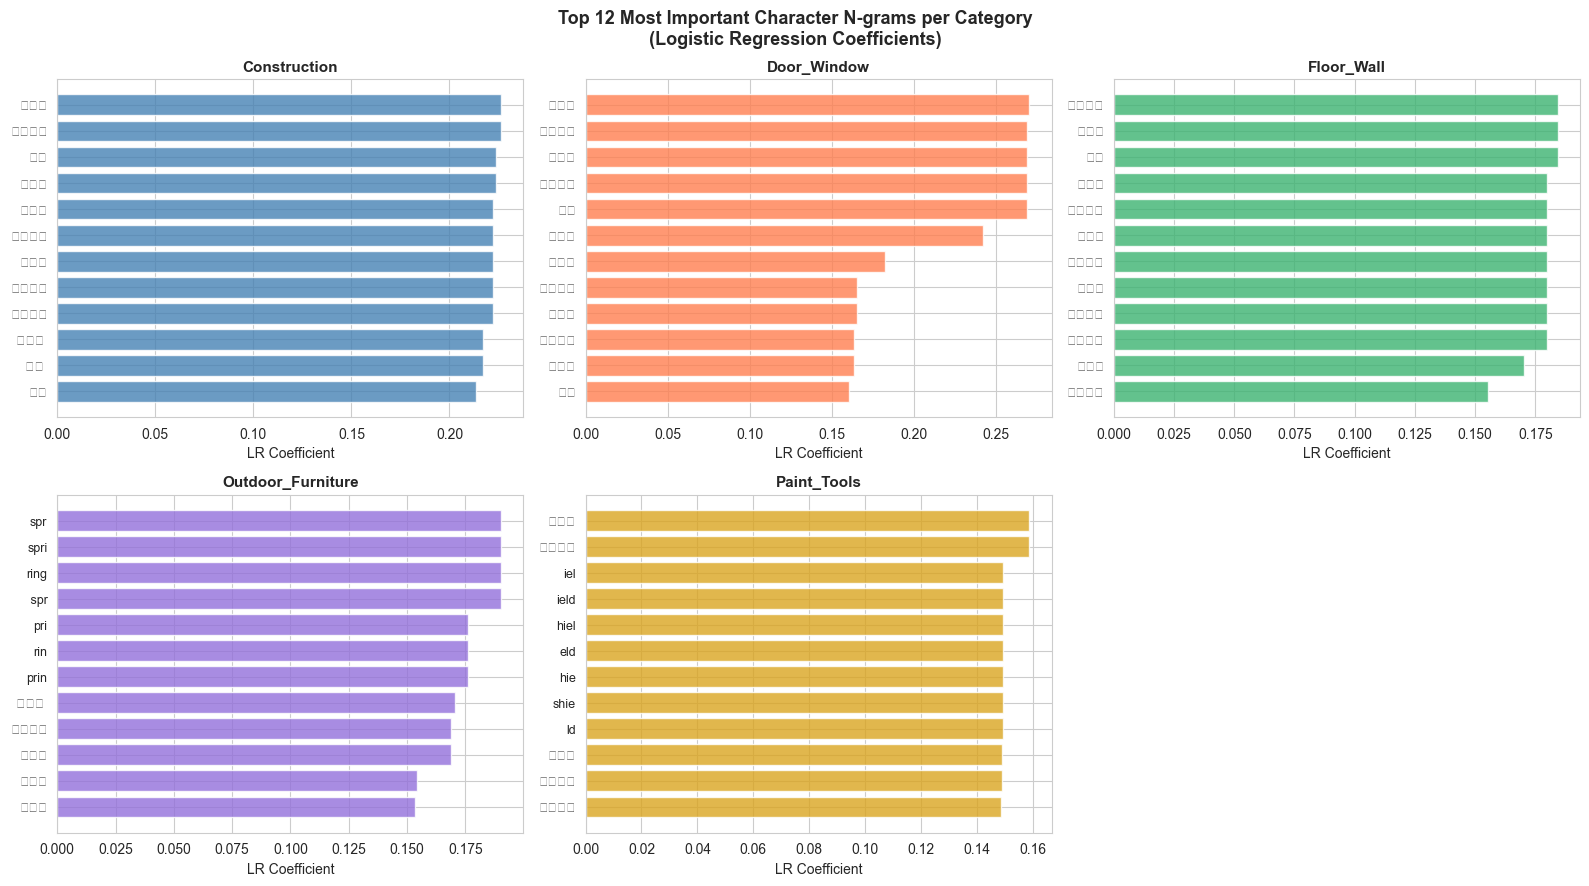

Each bar shows how strongly a character n-gram drives prediction for that category.


In [3]:
tfidf = pipeline.named_steps['tfidf']
clf = pipeline.named_steps['clf']

feature_names = tfidf.get_feature_names_out()
classes = clf.classes_
coefs = clf.coef_  # shape: (n_classes, n_features)

TOP_N = 12
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']

for i, (cls, coef, color) in enumerate(zip(classes, coefs, colors)):
    top_idx = np.argsort(coef)[-TOP_N:][::-1]
    top_features = feature_names[top_idx]
    top_weights = coef[top_idx]

    ax = axes[i]
    ax.barh(range(TOP_N), top_weights[::-1], color=color, alpha=0.8)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_features[::-1], fontsize=9)
    ax.set_title(f'{cls}', fontweight='bold', fontsize=11)
    ax.set_xlabel('LR Coefficient')

axes[-1].axis('off')
plt.suptitle('Top 12 Most Important Character N-grams per Category\n(Logistic Regression Coefficients)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('B5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Each bar shows how strongly a character n-gram drives prediction for that category.')

## 3. Decision Boundary Visualization via PCA

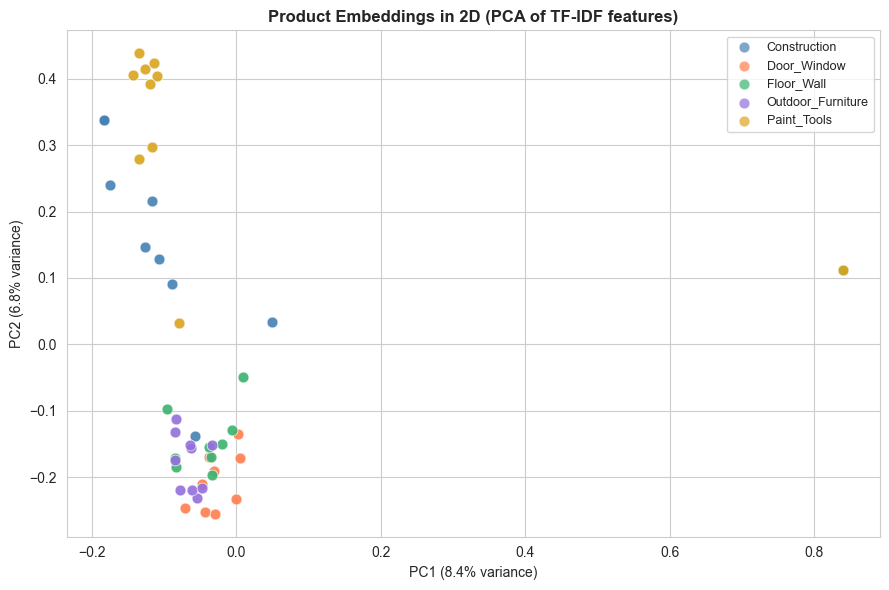

PC1+PC2 explain 15.2% of variance.


In [4]:
from sklearn.decomposition import PCA

X_all_tfidf = tfidf.transform(X)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_all_tfidf.toarray())

fig, ax = plt.subplots(figsize=(9, 6))
palette = dict(zip(classes, colors))
for cls in classes:
    mask = y == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=cls,
               color=palette[cls], alpha=0.7, s=60, edgecolors='white', linewidths=0.5)

ax.set_title('Product Embeddings in 2D (PCA of TF-IDF features)', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('B5_pca_decision_space.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'PC1+PC2 explain {sum(pca.explained_variance_ratio_)*100:.1f}% of variance.')

## 4. LIME Explanation for Individual Predictions

In [5]:
try:
    from lime.lime_text import LimeTextExplainer
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False
    print('LIME not installed. Run: pip install lime')
    print('Showing coefficient-based explanation instead.')

LIME not installed. Run: pip install lime
Showing coefficient-based explanation instead.


In [6]:
def explain_prediction(text, pipeline, top_n=8):
    """Show top character n-grams contributing to predicted class."""
    pred_class = pipeline.predict([text])[0]
    proba = pipeline.predict_proba([text])[0]
    classes = pipeline.named_steps['clf'].classes_
    proba_dict = dict(zip(classes, proba))

    tfidf = pipeline.named_steps['tfidf']
    clf = pipeline.named_steps['clf']
    feat_names = tfidf.get_feature_names_out()
    class_idx = list(classes).index(pred_class)
    coef = clf.coef_[class_idx]

    vec = tfidf.transform([text]).toarray()[0]
    contributions = vec * coef
    top_idx = np.argsort(contributions)[-top_n:][::-1]

    print(f'Text: "{text[:80]}..."')
    print(f'Predicted: {pred_class}')
    print('Class probabilities:')
    for c, p in sorted(proba_dict.items(), key=lambda x: -x[1]):
        bar = '█' * int(p * 30)
        print(f'  {c:25s}: {bar} {p:.3f}')
    print(f'\nTop contributing n-grams for "{pred_class}":')
    for idx in top_idx:
        if contributions[idx] > 0:
            print(f'  "{feat_names[idx]}"  → +{contributions[idx]:.4f}')
    print()

# Test on 3 samples from test set
for i in [0, 5, 10]:
    explain_prediction(X_test.iloc[i], pipeline)
    print('─' * 60)

Text: "ตัวจบต่างระดับ PVC INOVAR 4X240X1 ซม. สีเมเปิล ตัวจบต่างระดับ PVC INOVAR 4X240X1..."
Predicted: Floor_Wall
Class probabilities:
  Floor_Wall               : ██████████████ 0.472
  Outdoor_Furniture        : ████ 0.153
  Door_Window              : ████ 0.145
  Construction             : ███ 0.120
  Paint_Tools              : ███ 0.109

Top contributing n-grams for "Floor_Wall":
  "จบ"  → +0.0108
  "จบงา"  → +0.0070
  "จบง"  → +0.0070
  "นธร"  → +0.0067
  "นธรร"  → +0.0067
  "ธรร"  → +0.0067
  "ธรรม"  → +0.0067
  "ธร"  → +0.0067

────────────────────────────────────────────────────────────
Text: "สีน้ำทาภายนอก BEGER COOL DIAMONDSHIELD 15 สี JOYFUL GREEN #069-6 กึ่งเงา 9 ลิตร ..."
Predicted: Paint_Tools
Class probabilities:
  Paint_Tools              : ██████████████████ 0.607
  Construction             : ███ 0.103
  Floor_Wall               : ██ 0.100
  Outdoor_Furniture        : ██ 0.099
  Door_Window              : ██ 0.091

Top contributing n-grams for "Paint_Tools":
  "ทาภ"  →

## 5. Interpretation in Application Domain

The LR coefficient analysis reveals clear linguistic patterns:

- **Paint_Tools**: The model learns n-grams containing "สี" (color/paint), "ทาสี" (paint), "แปรง" (brush) — exactly the Thai words used in paint product descriptions
- **Door_Window**: N-grams from "ประตู" (door), "หน้าต่าง" (window), "บานเลื่อน" (sliding panel) dominate
- **Floor_Wall**: "กระเบื้อง" (tile), "พื้น" (floor), "ผนัง" (wall) drive this class
- **Construction**: "ปูน" (cement), "เหล็ก" (steel/iron), "วัสดุ" (material) are key features
- **Outdoor_Furniture**: "โต๊ะ" (table), "เก้าอี้" (chair), "สวน" (garden) are distinctive

This confirms the model is learning **semantically meaningful product vocabulary**, not spurious patterns. The character n-gram approach successfully captures Thai word substructures without requiring an explicit tokenizer.